In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
def set_seeds(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

Using device: cuda


In [3]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# Load CIFAR-10 dataset
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

# Create data loaders
batch_size = 64
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Total: ", len(trainset) + len(valset) + len(testset))
print(f"Training: {len(trainset)}, Validation: {len(valset)}, Test: {len(testset)}")

Total:  60000
Training: 40000, Validation: 10000, Test: 10000


In [5]:
class TeacherModel(nn.Module):
    def __init__(self, model_name='resnet18'):
        super(TeacherModel, self).__init__()
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            for param in self.backbone.parameters(): param.requires_grad = False
            for param in self.backbone.layer4.parameters(): param.requires_grad = True
            self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 10)
        elif model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=True)
            for param in self.backbone.features.parameters(): param.requires_grad = False
            for param in self.backbone.features[24:].parameters(): param.requires_grad = True
            num_features = self.backbone.classifier[0].in_features
            self.backbone.classifier = nn.Sequential(
                nn.Linear(num_features, 1024), nn.ReLU(True), nn.Dropout(0.5),
                nn.Linear(1024, 10)
            )
    def forward(self, x): return self.backbone(x)



In [6]:
class StudentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(StudentCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)), nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

In [7]:
def evaluate_model(model, data_loader):
    """Evaluate model accuracy on given data loader"""
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = running_loss / len(data_loader)
    return accuracy, avg_loss

In [8]:
def plot_training_curves(train_losses, train_accs, val_losses, val_accs, title):
    """Plot training and validation curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title(f'{title} - Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_title(f'{title} - Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [9]:
teacher_resnet = TeacherModel('resnet18').to(device)
teacher_vgg = TeacherModel('vgg16').to(device)

In [10]:
def train_teacher(model, name, epochs=5):
    print(f"Training teacher: {name}...")
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        pbar = tqdm(train_loader, desc=f"Teacher {name} | Epoch {epoch+1}")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        # Calculate epoch metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        val_acc, val_loss = evaluate_model(model, val_loader)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Plot training curves
    plot_training_curves(train_losses, train_accs, val_losses, val_accs, f"Teacher {name}")
    
    # Final evaluation on test set
    test_acc, test_loss = evaluate_model(model, test_loader)
    print(f"Final Test Accuracy for {name}: {test_acc:.2f}%")
    
    return model

Training teacher: ResNet18...


Teacher ResNet18 | Epoch 1: 100%|██████████| 625/625 [00:35<00:00, 17.42it/s, Loss=0.2487, Acc=84.15%]


Epoch 1: Train Loss: 0.4615, Train Acc: 84.15%, Val Loss: 0.3797, Val Acc: 86.39%


Teacher ResNet18 | Epoch 2: 100%|██████████| 625/625 [00:34<00:00, 18.03it/s, Loss=0.1200, Acc=92.28%]


Epoch 2: Train Loss: 0.2225, Train Acc: 92.28%, Val Loss: 0.3305, Val Acc: 88.91%


...

Epoch 3: Train Loss: 0.1191, Train Acc: 95.82%, Val Loss: 0.3786, Val Acc: 88.54%


Teacher ResNet18 | Epoch 4: 100%|██████████| 625/625 [00:36<00:00, 17.25it/s, Loss=0.0379, Acc=97.24%]


Epoch 4: Train Loss: 0.0816, Train Acc: 97.24%, Val Loss: 0.3809, Val Acc: 89.15%


Teacher ResNet18 | Epoch 5: 100%|██████████| 625/625 [00:36<00:00, 17.17it/s, Loss=0.1407, Acc=97.95%]


Epoch 5: Train Loss: 0.0603, Train Acc: 97.95%, Val Loss: 0.3943, Val Acc: 89.02%


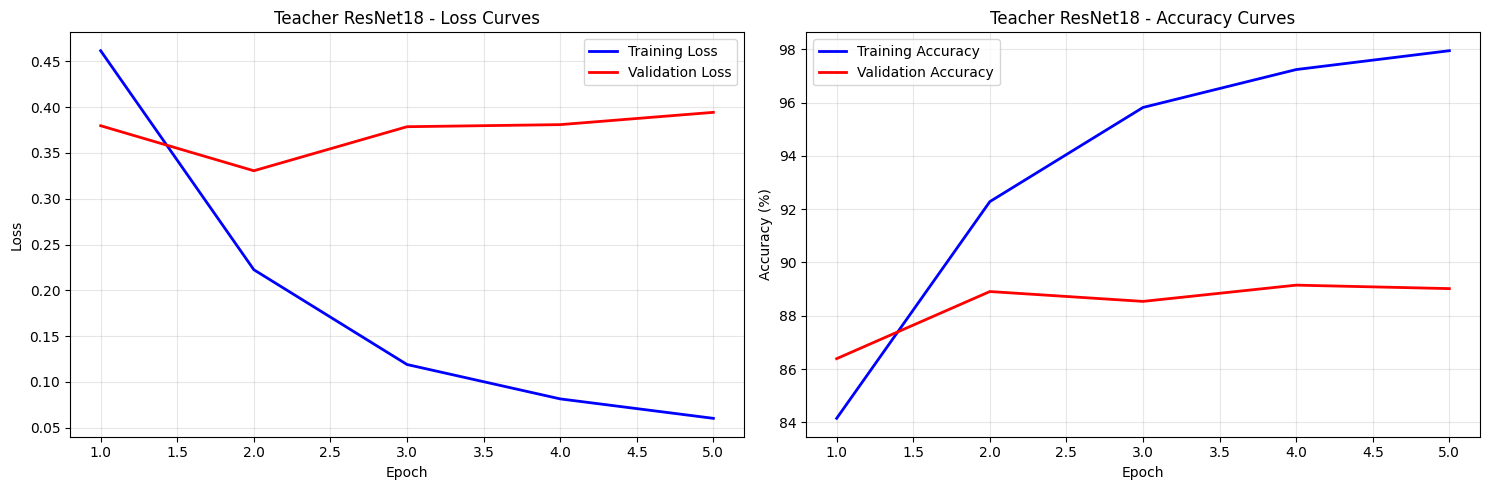

Final Test Accuracy for ResNet18: 88.69%


In [11]:
# Train teachers
teacher_resnet = train_teacher(teacher_resnet, 'ResNet18', epochs=5)

Training teacher: VGG16...


Teacher VGG16 | Epoch 1: 100%|██████████| 625/625 [02:08<00:00,  4.85it/s, Loss=0.8886, Acc=40.00%]


Epoch 1: Train Loss: 1.6212, Train Acc: 40.00%, Val Loss: 0.8764, Val Acc: 69.12%


Teacher VGG16 | Epoch 2: 100%|██████████| 625/625 [02:11<00:00,  4.77it/s, Loss=0.5868, Acc=75.33%]


Epoch 2: Train Loss: 0.7359, Train Acc: 75.33%, Val Loss: 0.6559, Val Acc: 77.57%


...

Epoch 3: Train Loss: 0.5233, Train Acc: 82.30%, Val Loss: 0.5487, Val Acc: 81.22%


Teacher VGG16 | Epoch 4: 100%|██████████| 625/625 [02:11<00:00,  4.76it/s, Loss=0.6721, Acc=86.17%]


Epoch 4: Train Loss: 0.4111, Train Acc: 86.17%, Val Loss: 0.5487, Val Acc: 82.56%


Teacher VGG16 | Epoch 5: 100%|██████████| 625/625 [02:11<00:00,  4.76it/s, Loss=0.3222, Acc=88.39%]


Epoch 5: Train Loss: 0.3383, Train Acc: 88.39%, Val Loss: 0.5442, Val Acc: 83.07%


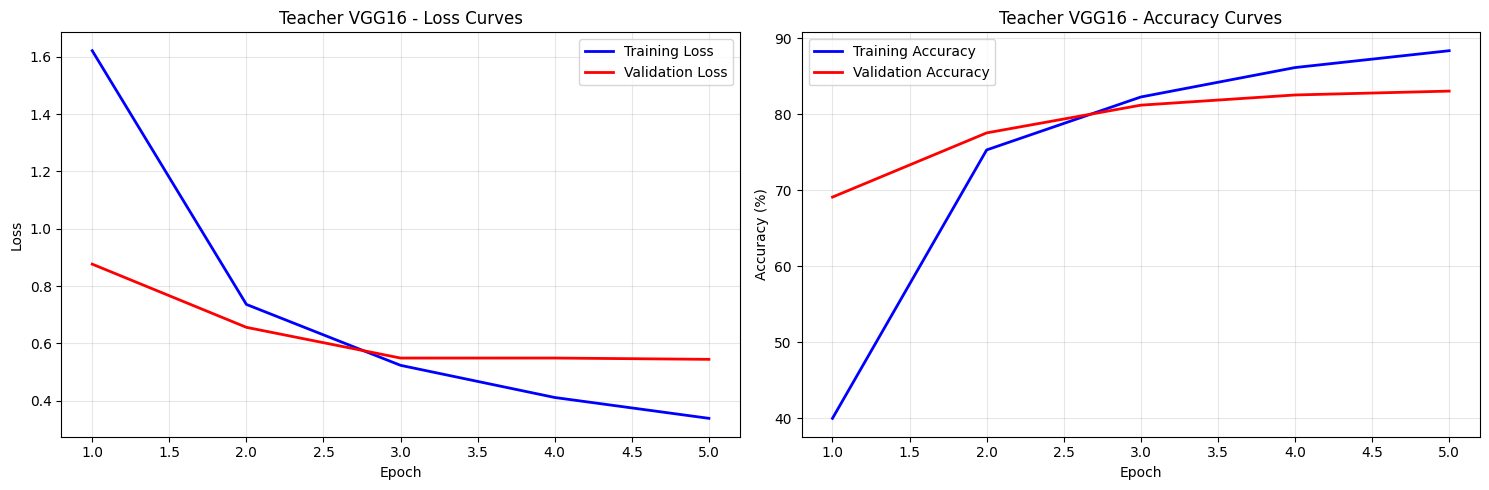

Final Test Accuracy for VGG16: 83.07%


In [12]:
teacher_vgg = train_teacher(teacher_vgg, 'VGG16', epochs=5)

In [13]:
teacher_resnet.eval()
teacher_vgg.eval()

TeacherModel(
  (backbone): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
    

In [14]:
class DistillationLoss(nn.Module):
    def __init__(self, T=3.0, alpha=0.7):
        super().__init__()
        self.T = T
        self.alpha = alpha
        self.kl_div = nn.KLDivLoss(reduction='batchmean')
        self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, s_logits, t_logits, labels):
        loss_distill = self.kl_div(F.log_softmax(s_logits/self.T, dim=1), F.softmax(t_logits/self.T, dim=1)) * (self.T**2)
        loss_ce = self.ce_loss(s_logits, labels)
        return self.alpha * loss_distill + (1 - self.alpha) * loss_ce

In [15]:
def train_student(student_model, teachers_list, num_epochs, description):
    student_model.train()
    for t in teachers_list: 
        t.eval()
    
    criterion = DistillationLoss() if teachers_list else nn.CrossEntropyLoss()
    optimizer = optim.Adam(student_model.parameters(), lr=0.001)
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    for epoch in range(num_epochs):
        # Training phase
        student_model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        pbar = tqdm(train_loader, desc=f"{description} | Epoch {epoch+1}")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            student_logits = student_model(data)
            
            if teachers_list:
                with torch.no_grad():
                    teacher_logits = torch.stack([t(data) for t in teachers_list]).mean(dim=0)
                loss = criterion(student_logits, teacher_logits, target)
            else: # Baseline case
                loss = criterion(student_logits, target)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(student_logits.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        # Calculate epoch metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        val_acc, val_loss = evaluate_model(student_model, val_loader)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Plot training curves
    plot_training_curves(train_losses, train_accs, val_losses, val_accs, description)
    
    # Final evaluation on test set
    test_acc, test_loss = evaluate_model(student_model, test_loader)
    print(f"Final Test Accuracy for {description}: {test_acc:.2f}%")
    
    return student_model, test_acc

In [16]:
NUM_EPOCHS_STUDENT = 10

Scenario 1: Training Baseline Student (no teachers)...


Baseline Student | Epoch 1: 100%|██████████| 625/625 [00:58<00:00, 10.71it/s, Loss=1.5711, Acc=36.88%]


Epoch 1: Train Loss: 1.7345, Train Acc: 36.88%, Val Loss: 1.4547, Val Acc: 46.93%


Baseline Student | Epoch 2: 100%|██████████| 625/625 [00:58<00:00, 10.63it/s, Loss=1.5537, Acc=45.40%]


Epoch 2: Train Loss: 1.4986, Train Acc: 45.40%, Val Loss: 1.3079, Val Acc: 52.81%


...

Epoch 8: Train Loss: 1.0208, Train Acc: 64.01%, Val Loss: 0.9106, Val Acc: 68.32%


Baseline Student | Epoch 9: 100%|██████████| 625/625 [00:58<00:00, 10.65it/s, Loss=0.8810, Acc=65.24%]


Epoch 9: Train Loss: 0.9856, Train Acc: 65.24%, Val Loss: 0.8846, Val Acc: 68.93%


Baseline Student | Epoch 10: 100%|██████████| 625/625 [00:58<00:00, 10.70it/s, Loss=1.0398, Acc=66.70%]


Epoch 10: Train Loss: 0.9472, Train Acc: 66.70%, Val Loss: 0.8478, Val Acc: 69.77%


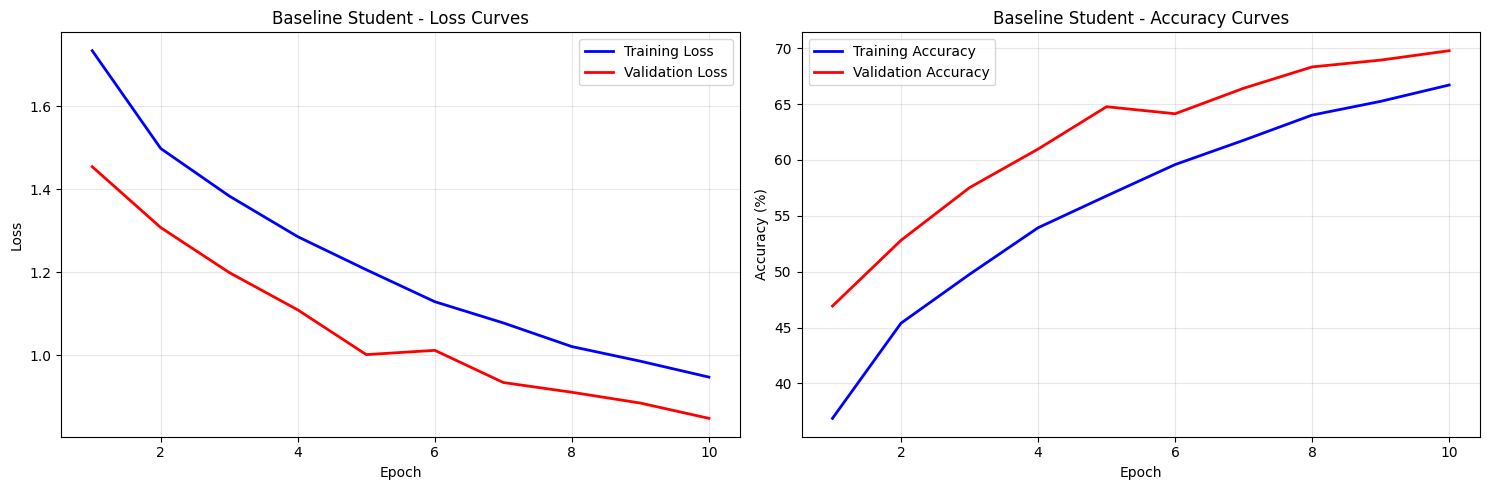

Final Test Accuracy for Baseline Student: 70.77%


In [17]:
print("Scenario 1: Training Baseline Student (no teachers)...")
set_seeds(42)
student_baseline = StudentCNN().to(device)
student_baseline, baseline_acc = train_student(student_baseline, [], NUM_EPOCHS_STUDENT, "Baseline Student")


Scenario 2: Distilling with 1 Teacher (ResNet18)...


Student with 1 Teacher | Epoch 1: 100%|██████████| 625/625 [01:17<00:00,  8.06it/s, Loss=7.0980, Acc=40.98%] 


Epoch 1: Train Loss: 8.0679, Train Acc: 40.98%, Val Loss: 1.6049, Val Acc: 51.32%


Student with 1 Teacher | Epoch 2: 100%|██████████| 625/625 [01:17<00:00,  8.04it/s, Loss=6.1341, Acc=51.05%]


Epoch 2: Train Loss: 6.6431, Train Acc: 51.05%, Val Loss: 1.4074, Val Acc: 58.06%


...

Epoch 8: Train Loss: 4.2069, Train Acc: 69.09%, Val Loss: 0.9985, Val Acc: 71.40%


Student with 1 Teacher | Epoch 9: 100%|██████████| 625/625 [01:17<00:00,  8.05it/s, Loss=4.0478, Acc=70.58%]


Epoch 9: Train Loss: 4.0498, Train Acc: 70.58%, Val Loss: 1.0026, Val Acc: 71.92%


Student with 1 Teacher | Epoch 10: 100%|██████████| 625/625 [01:17<00:00,  8.06it/s, Loss=3.9529, Acc=71.35%]


Epoch 10: Train Loss: 3.9047, Train Acc: 71.35%, Val Loss: 1.0067, Val Acc: 72.18%


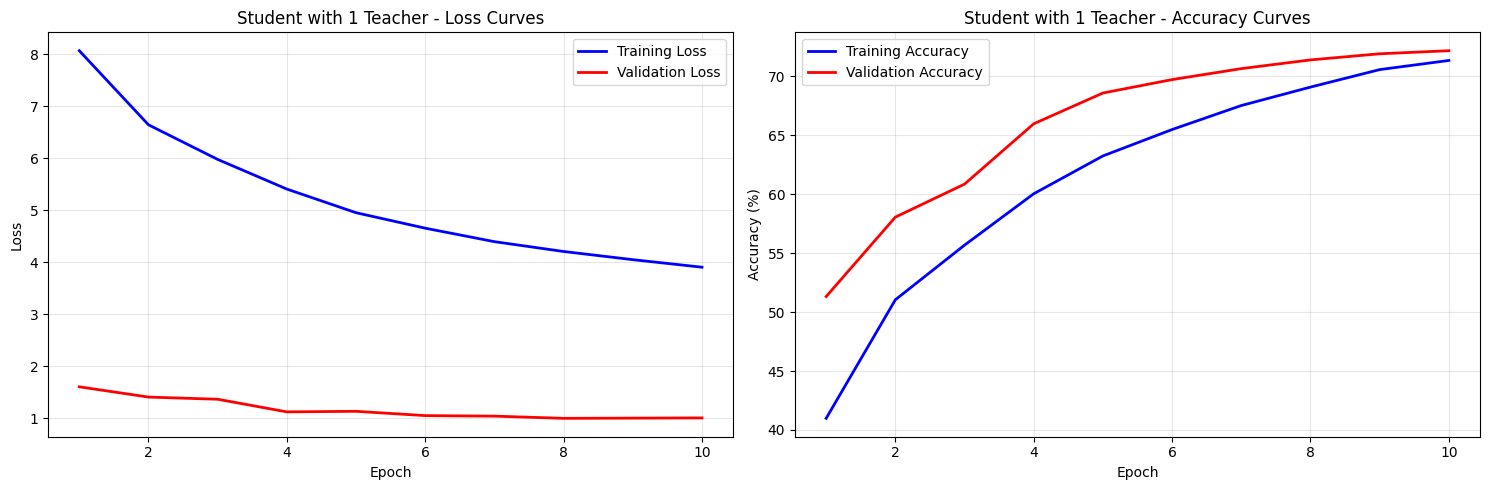

Final Test Accuracy for Student with 1 Teacher: 72.04%


In [18]:
print("\nScenario 2: Distilling with 1 Teacher (ResNet18)...")
set_seeds(42)
student_distilled_1T = StudentCNN().to(device)
student_distilled_1T, distilled_1T_acc = train_student(student_distilled_1T, [teacher_resnet], NUM_EPOCHS_STUDENT, "Student with 1 Teacher")


Scenario 3: Distilling with 2 Teachers (Ensemble)...


Student with 2 Teachers | Epoch 1: 100%|██████████| 625/625 [03:06<00:00,  3.34it/s, Loss=5.5727, Acc=41.08%]


Epoch 1: Train Loss: 7.2215, Train Acc: 41.08%, Val Loss: 1.4969, Val Acc: 52.30%


Student with 2 Teachers | Epoch 2: 100%|██████████| 625/625 [03:06<00:00,  3.34it/s, Loss=5.2871, Acc=51.83%]


Epoch 2: Train Loss: 5.7648, Train Acc: 51.83%, Val Loss: 1.4117, Val Acc: 58.00%


...

Epoch 8: Train Loss: 3.5012, Train Acc: 69.22%, Val Loss: 1.0755, Val Acc: 70.26%


Student with 2 Teachers | Epoch 9: 100%|██████████| 625/625 [03:06<00:00,  3.35it/s, Loss=3.6505, Acc=70.72%]


Epoch 9: Train Loss: 3.3638, Train Acc: 70.72%, Val Loss: 0.9728, Val Acc: 71.93%


Student with 2 Teachers | Epoch 10: 100%|██████████| 625/625 [03:06<00:00,  3.35it/s, Loss=3.4380, Acc=71.78%]


Epoch 10: Train Loss: 3.2238, Train Acc: 71.78%, Val Loss: 0.9749, Val Acc: 72.83%


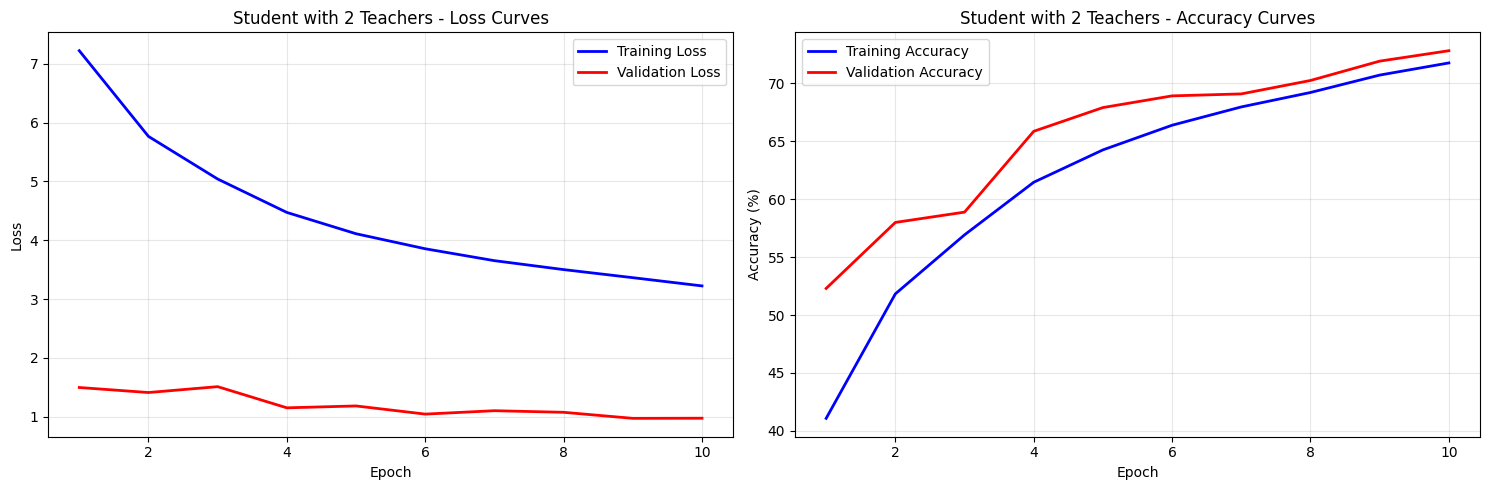

Final Test Accuracy for Student with 2 Teachers: 72.73%


In [19]:
print("\nScenario 3: Distilling with 2 Teachers (Ensemble)...")
set_seeds(42)
student_distilled_2T = StudentCNN().to(device)
student_distilled_2T, distilled_2T_acc = train_student(student_distilled_2T, [teacher_resnet, teacher_vgg], NUM_EPOCHS_STUDENT, "Student with 2 Teachers")

In [20]:
# Evaluate all models on test set
teacher_resnet_acc, _ = evaluate_model(teacher_resnet, test_loader)
teacher_vgg_acc, _ = evaluate_model(teacher_vgg, test_loader)

# Store all accuracies
accuracies = {
    "Teacher ResNet18": teacher_resnet_acc,
    "Teacher VGG16": teacher_vgg_acc,
    "Student Baseline": baseline_acc,
    "Student (1 Teacher)": distilled_1T_acc,
    "Student (2 Teachers)": distilled_2T_acc
}

print("\n--- Final Test Accuracies ---")
for name, acc in accuracies.items():
    print(f"{name:<20}: {acc:.2f}%")


--- Final Test Accuracies ---
Teacher ResNet18    : 88.69%
Teacher VGG16       : 83.07%
Student Baseline    : 70.77%
Student (1 Teacher) : 72.04%
Student (2 Teachers): 72.73%


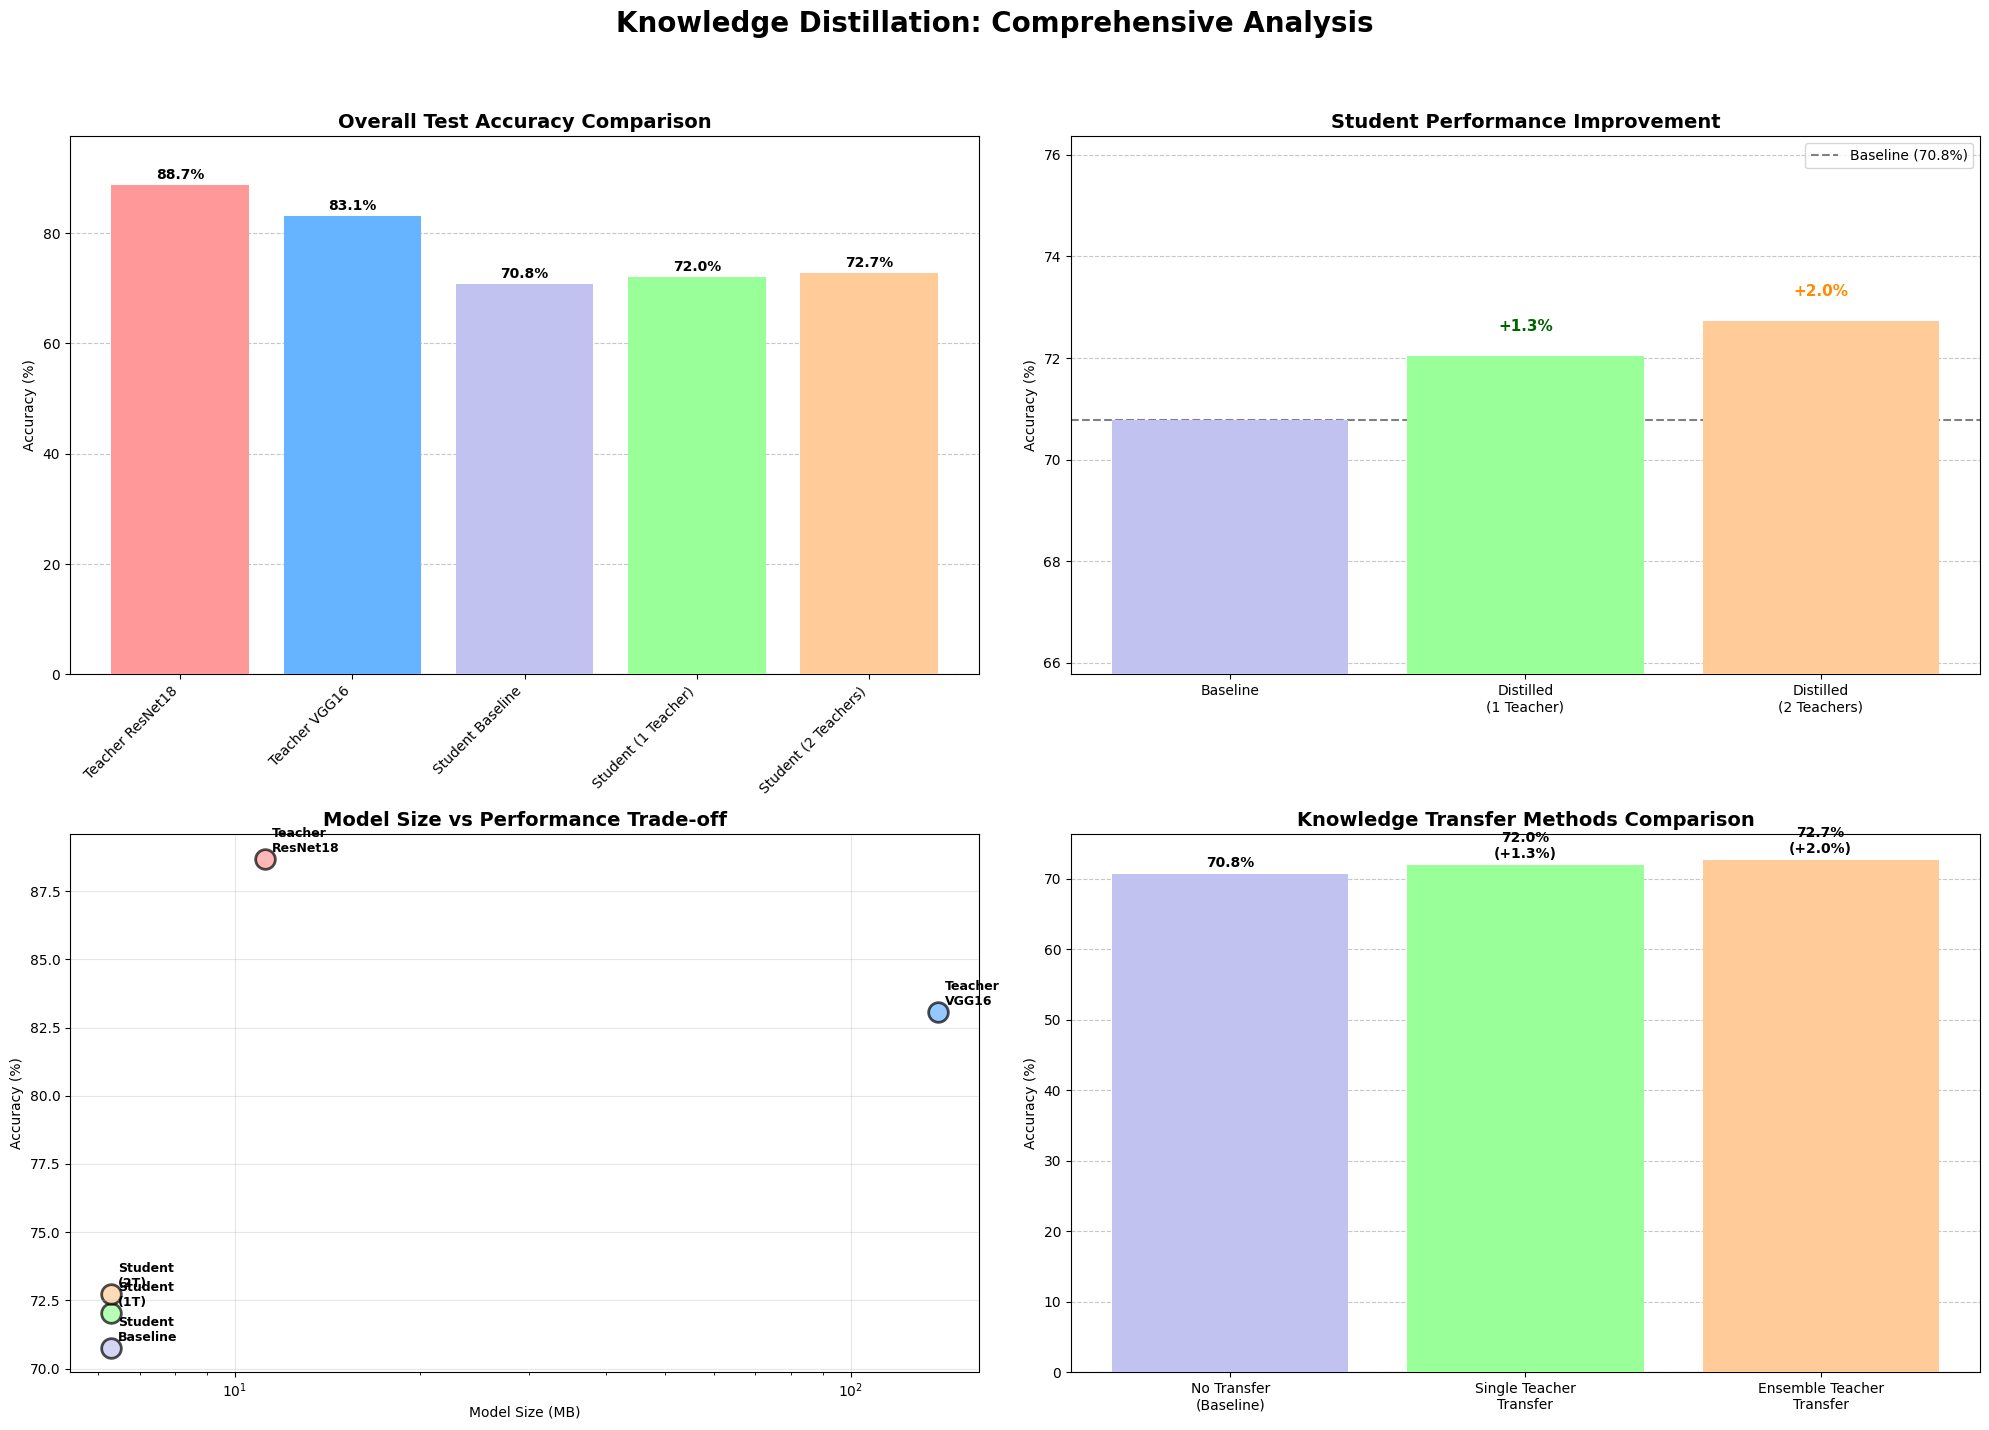

In [22]:
# Plot 1: Overall Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle("Knowledge Distillation: Comprehensive Analysis", fontsize=20, fontweight='bold')

# Subplot 1: Overall Accuracy Comparison
models = list(accuracies.keys())
acc_values = list(accuracies.values())
colors = ['#ff9999', '#66b3ff', '#c2c2f0', '#99ff99', '#ffcc99']

bars = axes[0, 0].bar(models, acc_values, color=colors, zorder=3)
axes[0, 0].set_title('Overall Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(0, max(acc_values) * 1.1)
# Fixed: Use setp for label rotation and alignment
plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

for bar in bars:
    yval = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, 
                   f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Student Performance Improvement
student_models = ['Baseline', 'Distilled\n(1 Teacher)', 'Distilled\n(2 Teachers)']
student_accs = [baseline_acc, distilled_1T_acc, distilled_2T_acc]
student_colors = ['#c2c2f0', '#99ff99', '#ffcc99']

bars = axes[0, 1].bar(student_models, student_accs, color=student_colors, zorder=3)
axes[0, 1].axhline(y=baseline_acc, color='grey', linestyle='--', 
                  label=f'Baseline ({baseline_acc:.1f}%)', zorder=1)
axes[0, 1].set_title('Student Performance Improvement', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_ylim(bottom=max(0, min(student_accs)-5))
axes[0, 1].legend()
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add improvement annotations
gain1 = distilled_1T_acc - baseline_acc
gain2 = distilled_2T_acc - baseline_acc
axes[0, 1].text(bars[1].get_x() + bars[1].get_width()/2.0, student_accs[1] + 0.5, 
               f'+{gain1:.1f}%', ha='center', color='darkgreen', fontweight='bold', fontsize=11)
axes[0, 1].text(bars[2].get_x() + bars[2].get_width()/2.0, student_accs[2] + 0.5, 
               f'+{gain2:.1f}%', ha='center', color='darkorange', fontweight='bold', fontsize=11)

# Subplot 3: Model Complexity vs Performance
model_names = ['Student\nBaseline', 'Student\n(1T)', 'Student\n(2T)', 'Teacher\nResNet18', 'Teacher\nVGG16']
model_accs = [baseline_acc, distilled_1T_acc, distilled_2T_acc, teacher_resnet_acc, teacher_vgg_acc]
model_sizes = [6.3, 6.3, 6.3, 11.2, 138.4]  # Approximate model sizes in MB

scatter_colors = ['#c2c2f0', '#99ff99', '#ffcc99', '#ff9999', '#66b3ff']
for i, (name, acc, size, color) in enumerate(zip(model_names, model_accs, model_sizes, scatter_colors)):
    axes[1, 0].scatter(size, acc, s=200, c=color, alpha=0.7, edgecolors='black', linewidth=2)
    axes[1, 0].annotate(name, (size, acc), xytext=(5, 5), textcoords='offset points', 
                       fontsize=9, fontweight='bold')

axes[1, 0].set_title('Model Size vs Performance Trade-off', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Model Size (MB)')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# Subplot 4: Knowledge Transfer Effectiveness
transfer_methods = ['No Transfer\n(Baseline)', 'Single Teacher\nTransfer', 'Ensemble Teacher\nTransfer']
transfer_accs = [baseline_acc, distilled_1T_acc, distilled_2T_acc]
transfer_colors = ['#c2c2f0', '#99ff99', '#ffcc99']

bars = axes[1, 1].bar(transfer_methods, transfer_accs, color=transfer_colors, zorder=3)
axes[1, 1].set_title('Knowledge Transfer Methods Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add percentage improvement annotations
for i, bar in enumerate(bars):
    yval = bar.get_height()
    if i == 0:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, 
                       f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        improvement = yval - baseline_acc
        axes[1, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, 
                       f'{yval:.1f}%\n(+{improvement:.1f}%)', ha='center', va='bottom', 
                       fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('knowledge_distillation_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()